Loading dataset information...


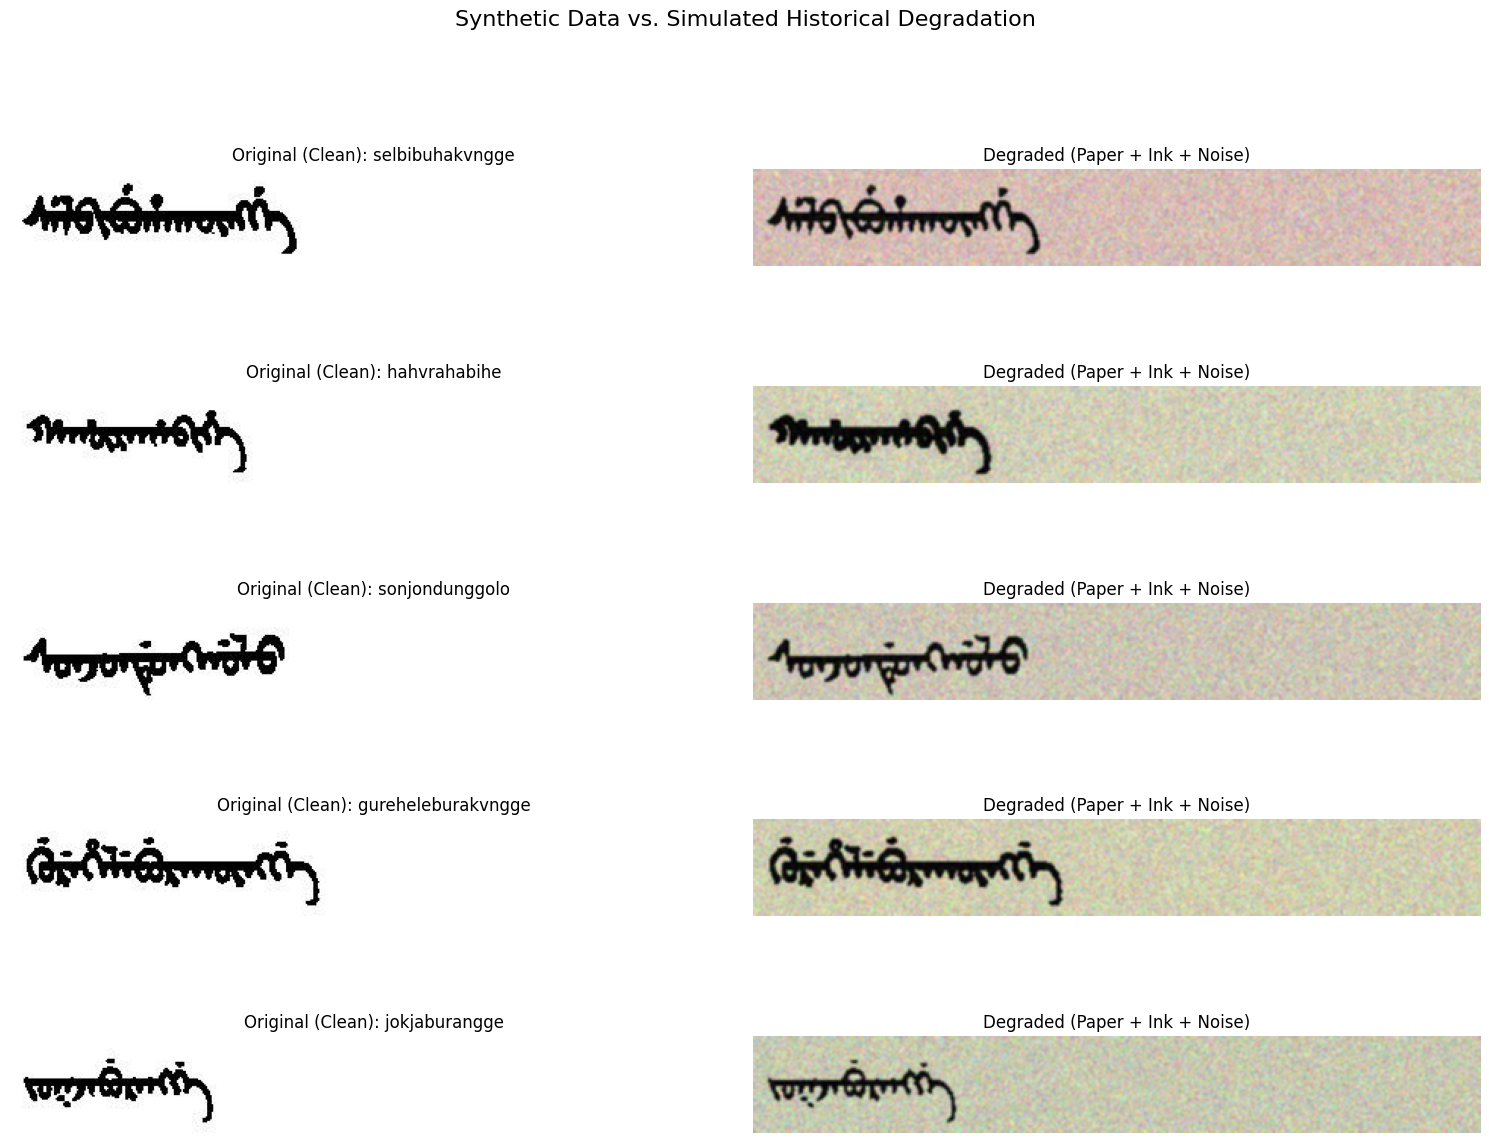

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===========================
# Path Configuration (Ensure these paths are accessible in your environment)
# ===========================
PARQUET_PATH = "/root/autodl-fs/Manchu_OCR/train.parquet"
IMAGE_DIR = "/root/autodl-fs/Manchu_OCR/train"

def simulate_historical_degradation(img_path):
    """
    Simulate physical degradation of historical documents using traditional CV methods.
    """
    # 1. Read image
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Unable to read image: {img_path}")
    
    h, w, c = img.shape
    
    # 2. Simulate ink bleed (thicker) or fading (thinner)
    # In historical documents, ink from brush/quill pens easily bleeds on paper or fades over time
    morph_choice = np.random.choice(['bleed', 'fade', 'none'], p=[0.4, 0.4, 0.2])
    
    if morph_choice == 'bleed':
        # Erosion shrinks the white background, making the black text thicker
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
        img = cv2.erode(img, kernel, iterations=1) 
    elif morph_choice == 'fade':
        # Dilation expands the white background, making the black text thinner or even causing broken strokes
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
        img = cv2.dilate(img, kernel, iterations=1)

    # 3. Simulate aged paper background color and uneven lighting (Multiply blending)
    # Historical paper usually appears yellowish or grayish-brown. Set a base BGR value and add random fluctuations
    base_b = np.random.randint(150, 190)
    base_g = np.random.randint(190, 210)
    base_r = np.random.randint(200, 220)
    
    # Generate a background with low-frequency fluctuations (simulating paper unevenness and aging)
    paper_bg = np.full((h, w, c), (base_b, base_g, base_r), dtype=np.float32)
    light_noise = np.random.normal(0, 15, (h, w, c)).astype(np.float32)
    paper_bg = np.clip(paper_bg + light_noise, 0, 255)
    
    # Blend the synthetic black-on-white text image with the background color
    img_float = img.astype(np.float32) / 255.0
    bg_float = paper_bg / 255.0
    blended = (img_float * bg_float) * 255.0
    img = blended.astype(np.uint8)

    # 4. Add high-frequency noise (simulating scanner impurities, paper fibers, and mold spots)
    noise = np.random.normal(0, 20, (h, w, c)).astype(np.float32)
    img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    # 5. Slight overall blur (simulating out-of-focus optics, image aging, or low-resolution scanning)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    # Convert to RGB format for correct display in matplotlib
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# ===========================
# Visualization Execution Module
# ===========================
print("Loading dataset information...")
df = pd.read_parquet(PARQUET_PATH)

# Randomly sample 5 records for visualization
sample_df = df.sample(n=5).reset_index(drop=True)

# Set matplotlib canvas size
fig, axes = plt.subplots(5, 2, figsize=(15, 12))
fig.suptitle("Synthetic Data vs. Simulated Historical Degradation", fontsize=16, y=1.02)

for i in range(5):
    filename = sample_df['filename'].iloc[i]
    text = sample_df['roman'].iloc[i]
    img_path = os.path.join(IMAGE_DIR, filename)
    
    # Read and convert original image
    orig_img = cv2.imread(img_path)
    if orig_img is None:
        print(f"Warning: Image not found {img_path}, skipped.")
        continue
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    
    # Generate degraded image
    degraded_img = simulate_historical_degradation(img_path)
    
    # Plot original image (left)
    axes[i, 0].imshow(orig_img_rgb)
    axes[i, 0].set_title(f"Original (Clean): {text}")
    axes[i, 0].axis('off')
    
    # Plot degraded image (right)
    axes[i, 1].imshow(degraded_img)
    axes[i, 1].set_title("Degraded (Paper + Ink + Noise)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [2]:
!pip install -q transformers
!pip install -q datasets jiwer evaluate
!pip install -q scikit-learn
!pip install -q pandas numpy

In [3]:
!pip install -q accelerate

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-



import os
os.environ['HF_ENDPOINT']= 'https://hf-mirror.com'
import torch
import pandas as pd
from PIL import Image
from pathlib import Path
from typing import List, Dict, Optional
from sklearn.model_selection import train_test_split

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    AutoTokenizer,
    PreTrainedTokenizerFast,
)
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers, processors
from torch.utils.data import Dataset

# ===========================
# 配置
# ===========================

CONFIG = {
    # 数据路径
    'data_parquet': "/root/autodl-fs/Manchu_OCR/train.parquet",
    'image_dir': "/root/autodl-fs/Manchu_OCR/train",
    
    # 输出路径
    'tokenizer_path': "./manchu_tokenizer",
    'output_dir_phase1': "./trocr_manchu_phase1_embedding",
    'output_dir_phase2': "./trocr_manchu_phase2_full",
    
    # Tokenizer配置
    'vocab_size': 8000,
    'min_frequency': 2,
    
    # Phase 1: 只训练embedding层（快速适应新vocabulary）
    'phase1_epochs': 10,  # [修改] 增加轮数
    'phase1_batch_size': 48,
    'phase1_lr_embedding': 5e-4,  # embedding层大学习率
    'phase1_lr_transformer': 1e-6,  # transformer几乎冻结
    
    # Phase 2: 全模型微调
    'phase2_epochs': 20,  # [修改] 增加轮数
    'phase2_batch_size': 16,
    'phase2_lr_embedding': 5e-5,  # embedding层中等学习率
    'phase2_lr_transformer': 2e-5,  # transformer小学习率
    'phase2_lr_encoder': 1e-5,  # 编码器更小的学习率
    
    # 通用配置
    'test_size': 0.1,
    'max_target_length': 128,
    'warmup_steps': 500,
}


# ===========================
# Tokenizer训练
# ===========================

class ManchuTokenizerTrainer:
    """满文专用tokenizer训练器"""
    
    def __init__(self, vocab_size=8000, min_frequency=2):
        self.vocab_size = vocab_size
        self.min_frequency = min_frequency
    
    def train_from_texts(self, texts: List[str], save_path: str):
        """从满文文本训练BPE tokenizer"""
        
        print("\n" + "=" * 60)
        print("训练满文专用Tokenizer")
        print("=" * 60)
        
        tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
        tokenizer.decoder = decoders.BPEDecoder()
        
        trainer = trainers.BpeTrainer(
            vocab_size=self.vocab_size,
            min_frequency=self.min_frequency,
            special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"],
            show_progress=True,
        )
        
        print(f"\n开始训练BPE tokenizer...")
        print(f"  词汇表大小: {self.vocab_size}")
        print(f"  训练文本数: {len(texts)}")
        
        temp_file = "/tmp/manchu_texts.txt"
        with open(temp_file, 'w', encoding='utf-8') as f:
            for text in texts:
                f.write(text + "\n")
        
        tokenizer.train([temp_file], trainer)
        
        tokenizer.post_processor = processors.TemplateProcessing(
            single="[CLS] $A [SEP]",
            pair="[CLS] $A [SEP] $B:1 [SEP]:1",
            special_tokens=[
                ("[CLS]", tokenizer.token_to_id("[CLS]")),
                ("[SEP]", tokenizer.token_to_id("[SEP]")),
            ],
        )
        
        os.makedirs(save_path, exist_ok=True)
        tokenizer.save(os.path.join(save_path, "tokenizer.json"))
        
        tokenizer_transformers = PreTrainedTokenizerFast(
            tokenizer_object=tokenizer,
            unk_token="[UNK]",
            pad_token="[PAD]",
            cls_token="[CLS]",
            sep_token="[SEP]",
            mask_token="[MASK]",
        )
        
        tokenizer_transformers.save_pretrained(save_path)
        print(f"\n✓ Tokenizer已保存到: {save_path}")
        
        return tokenizer_transformers


# ===========================
# 智能初始化策略
# ===========================

def smart_initialize_embeddings(model, old_tokenizer, new_tokenizer, old_embeddings, old_lm_head):
  
    print("\n" + "=" * 60)
    print("智能初始化Embedding层")
    print("=" * 60)
    
    old_vocab = old_tokenizer.get_vocab()
    new_vocab = new_tokenizer.get_vocab()
    old_vocab_size = len(old_vocab)
    
    new_embeddings = model.decoder.get_input_embeddings().weight.data
    new_lm_head_weight = model.decoder.get_output_embeddings().weight.data
    
    # 统计
    exact_match = 0
    partial_match = 0
    random_init = 0
    
    for token, new_id in new_vocab.items():
        # 策略1: 完全匹配
        if token in old_vocab:
            old_id = old_vocab[token]
            if old_id < old_vocab_size:  # 安全检查
                new_embeddings[new_id] = old_embeddings[old_id]
                new_lm_head_weight[new_id] = old_lm_head[old_id]
                exact_match += 1
            else:
                random_init += 1
        
        # 策略2: 部分匹配（对于复合token）
        elif len(token) > 3 and not token.startswith('['):
            # 尝试找到token的子串
            sub_embeddings = []
            for i in range(len(token)):
                for j in range(i+1, min(len(token)+1, i+5)):
                    sub_token = token[i:j]
                    if sub_token in old_vocab:
                        old_id = old_vocab[sub_token]
                        if old_id < old_vocab_size and len(sub_token) >= 2:
                            sub_embeddings.append(old_embeddings[old_id])
            
            if sub_embeddings:
                new_embeddings[new_id] = torch.stack(sub_embeddings).mean(dim=0)
                # LM head也用类似的平均
                new_lm_head_weight[new_id] = torch.stack([
                    old_lm_head[old_vocab[token[i:j]]] 
                    for i in range(len(token))
                    for j in range(i+1, min(len(token)+1, i+5))
                    if token[i:j] in old_vocab and old_vocab[token[i:j]] < old_vocab_size and len(token[i:j]) >= 2
                ][:len(sub_embeddings)]).mean(dim=0)
                partial_match += 1
            else:
                random_init += 1
        else:
            random_init += 1
    
    print(f"初始化统计:")
    print(f"  完全匹配: {exact_match} ({100*exact_match/len(new_vocab):.1f}%)")
    print(f"  部分匹配: {partial_match} ({100*partial_match/len(new_vocab):.1f}%)")
    print(f"  随机初始化: {random_init} ({100*random_init/len(new_vocab):.1f}%)")
    
    return model


# ===========================
# 数据集
# ===========================

class ManchuOCRDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_name = self.df['filename'].iloc[idx]
        text = self.df['roman'].iloc[idx]
        
        image_path = os.path.join(self.root_dir, file_name)
        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True
        ).input_ids
        
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 
                  for label in labels]

        return {
            "pixel_values": pixel_values.squeeze(),
            "labels": torch.tensor(labels)
        }


from dataclasses import dataclass

@dataclass
class VisionSeq2SeqDataCollator:
    def __call__(self, features: List[Dict[str, torch.Tensor]]) -> Dict[str, torch.Tensor]:
        return {
            "pixel_values": torch.stack([f["pixel_values"] for f in features]),
            "labels": torch.stack([f["labels"] for f in features]),
        }


# ===========================
# 差异化学习率训练器
# ===========================

class DifferentialLRTrainer(Seq2SeqTrainer):

    
    def __init__(self, lr_embedding, lr_transformer, lr_encoder=None, *args, **kwargs):
        self.lr_embedding = lr_embedding
        self.lr_transformer = lr_transformer
        self.lr_encoder = lr_encoder
        super().__init__(*args, **kwargs)
    
    def create_optimizer(self):
        
        if self.optimizer is None:
            decay_parameters = self.get_decay_parameter_names(self.model)
            
            # 编码器参数
            encoder_params = []
            if self.lr_encoder is not None:
                for n, p in self.model.encoder.named_parameters():
                    if p.requires_grad:
                        encoder_params.append(p)
            
            # 解码器embedding参数
            embedding_params = []
            for n, p in self.model.decoder.named_parameters():
                if p.requires_grad and ('embed' in n or 'lm_head' in n):
                    embedding_params.append(p)
            
            # 解码器transformer参数
            transformer_params = []
            for n, p in self.model.decoder.named_parameters():
                if p.requires_grad and 'embed' not in n and 'lm_head' not in n:
                    transformer_params.append(p)
            
            # 构建参数组
            optimizer_grouped_parameters = []
            
            if encoder_params and self.lr_encoder is not None:
                optimizer_grouped_parameters.append({
                    "params": encoder_params,
                    "lr": self.lr_encoder,
                    "weight_decay": self.args.weight_decay,
                })
                print(f"编码器参数: {sum(p.numel() for p in encoder_params):,}, lr={self.lr_encoder}")
            
            optimizer_grouped_parameters.extend([
                {
                    "params": embedding_params,
                    "lr": self.lr_embedding,
                    "weight_decay": self.args.weight_decay,
                },
                {
                    "params": transformer_params,
                    "lr": self.lr_transformer,
                    "weight_decay": self.args.weight_decay,
                }
            ])
            
            print(f"Embedding参数: {sum(p.numel() for p in embedding_params):,}, lr={self.lr_embedding}")
            print(f"Transformer参数: {sum(p.numel() for p in transformer_params):,}, lr={self.lr_transformer}")
            
            self.optimizer = torch.optim.AdamW(
                optimizer_grouped_parameters,
                betas=(self.args.adam_beta1, self.args.adam_beta2),
                eps=self.args.adam_epsilon,
            )
        
        return self.optimizer


# ===========================
# 评估指标
# ===========================

def create_compute_metrics(tokenizer):
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = [[(l if l != -100 else tokenizer.pad_token_id) for l in row] 
                  for row in labels]
        pred_str = tokenizer.batch_decode(preds, skip_special_tokens=True)
        label_str = tokenizer.batch_decode(labels, skip_special_tokens=True)
        
        # CER
        try:
            import evaluate
            cer_metric = evaluate.load("cer")
            cer = cer_metric.compute(predictions=pred_str, references=label_str)
        except:
            cer = 0.0
        
        # 词级准确率
        word_correct = 0
        word_total = 0
        for pred, label in zip(pred_str, label_str):
            pred_words = set(pred.split())
            label_words = set(label.split())
            word_correct += len(pred_words & label_words)
            word_total += len(label_words)
        
        word_accuracy = word_correct / max(word_total, 1)
        
        return {
            "cer": cer,
            "word_accuracy": word_accuracy
        }
    
    return compute_metrics


# ===========================
# 主训练流程
# ===========================

def main():
    
    # 加载数据
    print("\n[1/7] 加载数据...")
    df = pd.read_parquet(CONFIG['data_parquet'])
    train_df, eval_df = train_test_split(df, test_size=CONFIG['test_size'], random_state=42)
    train_df.reset_index(drop=True, inplace=True)
    eval_df.reset_index(drop=True, inplace=True)
    print(f"训练集: {len(train_df)}, 验证集: {len(eval_df)}")
    
    # 训练tokenizer
    print("\n[2/7] 准备满文tokenizer...")
    if not os.path.exists(CONFIG['tokenizer_path']):
        texts = df['roman'].tolist()
        trainer = ManchuTokenizerTrainer(
            vocab_size=CONFIG['vocab_size'],
            min_frequency=CONFIG['min_frequency']
        )
        manchu_tokenizer = trainer.train_from_texts(texts, CONFIG['tokenizer_path'])
    else:
        print(f"加载已有tokenizer: {CONFIG['tokenizer_path']}")
        manchu_tokenizer = PreTrainedTokenizerFast.from_pretrained(CONFIG['tokenizer_path'])
    
    # 加载模型
    print("\n[3/7] 加载TrOCR模型...")
    original_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
    model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
    
    # 调整模型
    old_vocab_size = original_processor.tokenizer.vocab_size
    new_vocab_size = len(manchu_tokenizer)
    print(f"词汇表: {old_vocab_size} → {new_vocab_size}")
    
    # 在resize之前保存旧的embedding权重
    old_embeddings = model.decoder.get_input_embeddings().weight.data.clone()
    old_lm_head = model.decoder.get_output_embeddings().weight.data.clone()
    
    # 调整embedding大小
    model.decoder.resize_token_embeddings(new_vocab_size)
    
    # 智能初始化（使用保存的旧权重）
    model = smart_initialize_embeddings(
        model, 
        original_processor.tokenizer, 
        manchu_tokenizer,
        old_embeddings,
        old_lm_head
    )
    
    # 配置模型
    model.config.decoder_start_token_id = manchu_tokenizer.cls_token_id
    model.config.pad_token_id = manchu_tokenizer.pad_token_id
    model.config.eos_token_id = manchu_tokenizer.sep_token_id
    model.config.vocab_size = new_vocab_size
    model.config.max_length = 128
    
    model.decoder.config.vocab_size = new_vocab_size
    
    processor = TrOCRProcessor(
        image_processor=original_processor.image_processor,
        tokenizer=manchu_tokenizer
    )
    
    # 创建数据集
    print("\n[4/7] 创建数据集...")
    train_dataset = ManchuOCRDataset(CONFIG['image_dir'], train_df, processor)
    eval_dataset = ManchuOCRDataset(CONFIG['image_dir'], eval_df, processor)
    
    # ===== Phase 1: 主要训练embedding层 =====
    print("\n[5/7] Phase 1: 快速适应新vocabulary（主要训练embedding）...")
    print("=" * 60)
    
    training_args_phase1 = Seq2SeqTrainingArguments(
        output_dir=CONFIG['output_dir_phase1'],
        per_device_train_batch_size=CONFIG['phase1_batch_size'],
        per_device_eval_batch_size=CONFIG['phase1_batch_size'],
        num_train_epochs=CONFIG['phase1_epochs'],
        learning_rate=CONFIG['phase1_lr_embedding'], 
        warmup_steps=200,
        logging_steps=50,
        save_steps=500,  # 保存ckpt防断线
        eval_strategy="no",  # [修改] 彻底关闭自动验证
        save_total_limit=2,
        predict_with_generate=True,
        generation_max_length=128,
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=4,
        report_to="none",
        remove_unused_columns=False,
    )
    
    trainer_phase1 = DifferentialLRTrainer(
        lr_embedding=CONFIG['phase1_lr_embedding'],
        lr_transformer=CONFIG['phase1_lr_transformer'],
        lr_encoder=None,  # Phase 1不训练编码器
        model=model,
        args=training_args_phase1,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=VisionSeq2SeqDataCollator(),
        processing_class=manchu_tokenizer,
        compute_metrics=create_compute_metrics(manchu_tokenizer),
    )
    
    # 冻结编码器
    for param in model.encoder.parameters():
        param.requires_grad = False
    
    print(f"Phase 1配置:")
    print(f"  Embedding学习率: {CONFIG['phase1_lr_embedding']}")
    print(f"  Transformer学习率: {CONFIG['phase1_lr_transformer']} (几乎冻结)")
    print(f"  编码器: 冻结")
    
    trainer_phase1.train()
    
    # [新增] Phase 1 结束后，手动进行唯一一次验证
    print("\n[!] Phase 1 训练结束，开始进行本阶段最终评估 (耗时较长，请耐心等待)...")
    metrics_phase1 = trainer_phase1.evaluate()
    print(f"Phase 1 最终验证结果: {metrics_phase1}")
    
    trainer_phase1.save_model(CONFIG['output_dir_phase1'])
    
    # ===== Phase 2: 全模型联合微调 =====
    print("\n[6/7] Phase 2: 全模型联合微调...")
    print("=" * 60)
    
    # 解冻编码器
    for param in model.encoder.parameters():
        param.requires_grad = True
    
    training_args_phase2 = Seq2SeqTrainingArguments(
        output_dir=CONFIG['output_dir_phase2'],
        per_device_train_batch_size=CONFIG['phase2_batch_size'],
        per_device_eval_batch_size=CONFIG['phase2_batch_size'],
        num_train_epochs=CONFIG['phase2_epochs'],
        learning_rate=CONFIG['phase2_lr_transformer'],
        warmup_steps=CONFIG['warmup_steps'],
        logging_steps=50,
        save_steps=2000,
        eval_strategy="no",  # [修改] 彻底关闭自动验证
        save_total_limit=3,
        predict_with_generate=True,
        generation_max_length=128,
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=4,
        report_to="none",
        # [修改] 已彻底移除 load_best_model_at_end 相关的参数，防止报错
        remove_unused_columns=False,
    )
    
    trainer_phase2 = DifferentialLRTrainer(
        lr_embedding=CONFIG['phase2_lr_embedding'],
        lr_transformer=CONFIG['phase2_lr_transformer'],
        lr_encoder=CONFIG['phase2_lr_encoder'],
        model=model,
        args=training_args_phase2,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=VisionSeq2SeqDataCollator(),
        processing_class=manchu_tokenizer,
        compute_metrics=create_compute_metrics(manchu_tokenizer),
    )
    
    print(f"Phase 2配置:")
    print(f"  Embedding学习率: {CONFIG['phase2_lr_embedding']}")
    print(f"  Transformer学习率: {CONFIG['phase2_lr_transformer']}")
    print(f"  编码器学习率: {CONFIG['phase2_lr_encoder']}")
    
    trainer_phase2.train()
    
    # [新增] Phase 2 结束后，手动进行唯一一次验证
    print("\n[!] Phase 2 训练结束，开始进行最终模型评估...")
    metrics_phase2 = trainer_phase2.evaluate()
    print(f"Phase 2 最终验证结果: {metrics_phase2}")
    
    # 保存最终模型
    print("\n[7/7] 保存最终模型...")
    trainer_phase2.save_model(CONFIG['output_dir_phase2'])
    processor.save_pretrained(CONFIG['output_dir_phase2'])
    
    print("\n" + "=" * 60)
    print("✓ 训练与验证全部完成！")
    print("=" * 60)
    print(f"Phase 1模型: {CONFIG['output_dir_phase1']}")
    print(f"Phase 2模型: {CONFIG['output_dir_phase2']}")


if __name__ == "__main__":
    main()

[1/7] 加载数据...
训练集: 54000, 验证集: 6000

[2/7] 准备满文tokenizer...
加载已有tokenizer: ./manchu_tokenizer

[3/7] 加载TrOCR模型...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


词汇表: 50265 → 8000

智能初始化Embedding层
初始化统计:
  完全匹配: 438 (5.5%)
  部分匹配: 7209 (90.1%)
  随机初始化: 353 (4.4%)

[4/7] 创建数据集...

[5/7] Phase 1: 快速适应新vocabulary（主要训练embedding）...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None, 'pad_token_id': 0}.


Phase 1配置:
  Embedding学习率: 0.0005
  Transformer学习率: 1e-06 (几乎冻结)
  编码器: 冻结
Embedding参数: 8,720,384, lr=0.0005
Transformer参数: 195,268,608, lr=1e-06


...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None}.



[6/7] Phase 2: 全模型联合微调...
Phase 2配置:
  Embedding学习率: 5e-05
  Transformer学习率: 2e-05
  编码器学习率: 1e-05
编码器参数: 86,653,440, lr=1e-05
Embedding参数: 8,720,384, lr=5e-05
Transformer参数: 195,268,608, lr=2e-05


Step,Training Loss
50,0.149600
100,0.197600
150,0.204800
200,0.242300
250,0.295900
300,0.298000
350,0.337900
400,0.367000
450,0.366100
500,0.431900



[!] Phase 2 训练结束，开始进行最终模型评估...


Phase 2 最终验证结果: {'eval_loss': 0.9007986783981323, 'eval_cer': 0.07505011489757003, 'eval_word_accuracy': 0.7543333333333333, 'eval_runtime': 706.0903, 'eval_samples_per_second': 8.497, 'eval_steps_per_second': 0.531, 'epoch': 20.0}

[7/7] 保存最终模型...

✓ 训练与验证全部完成！
Phase 1模型: ./trocr_manchu_phase1_embedding
Phase 2模型: ./trocr_manchu_phase2_full
